# Level 3 - Advanced Analytics: Supervised Classification & Churn Prediction

### Objectives:
1. Encode categorical features and prepare train/test splits (80/20 stratified).
2. Train a Decision Tree Classifier to predict Customer Churn.
3. Evaluate classification performance (Precision, Recall, F1-score, Confusion Matrix).
4. Extract feature importances to determine primary drivers of churn.


In [2]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Load data from Desktop automatically
desktop_csvs = glob.glob(os.path.expanduser('~/Desktop/*.csv'))
df = pd.read_csv(desktop_csvs[0])

# 2. Encode binary categorical columns
# Convert 'International plan' and 'Voice mail plan' (yes/no -> 1/0)
df['International plan'] = (
    df['International plan'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
).fillna(0)
df['Voice mail plan'] = (
    df['Voice mail plan'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
).fillna(0)
df['Churn'] = df['Churn'].astype(int)

# 3. Select Features (X) and Target (y)
feature_cols = [
    'Account length',
    'Number vmail messages',
    'Total day minutes',
    'Total day calls',
    'Total day charge',
    'Total eve minutes',
    'Total eve calls',
    'Total eve charge',
    'Total night minutes',
    'Total night calls',
    'Total night charge',
    'Total intl minutes',
    'Total intl calls',
    'Total intl charge',
    'Customer service calls',
    'International plan',
    'Voice mail plan',
]

X = df[feature_cols]
y = df['Churn']

# 4. Stratified 80/20 train-test split (maintains class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(
    f'Training Set: {X_train.shape[0]} rows | Churn Distribution:\n{y_train.value_counts()}'
)
print(
    f'\nTesting Set:  {X_test.shape[0]} rows | Churn Distribution:\n{y_test.value_counts()}'
)

Training Set: 533 rows | Churn Distribution:
Churn
0    457
1     76
Name: count, dtype: int64

Testing Set:  134 rows | Churn Distribution:
Churn
0    115
1     19
Name: count, dtype: int64


In [3]:
# 5. Initialize and train Decision Tree with max_depth to prevent overfitting
dt_model = DecisionTreeClassifier(
    max_depth=4, criterion='gini', random_state=42
)
dt_model.fit(X_train, y_train)

# 6. Predictions
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

print('Model Training Completed successfully.')

Model Training Completed successfully.


--- Classification Report ---
              precision    recall  f1-score   support

Retained (0)       0.92      0.99      0.95       115
 Churned (1)       0.90      0.47      0.62        19

    accuracy                           0.92       134
   macro avg       0.91      0.73      0.79       134
weighted avg       0.92      0.92      0.91       134



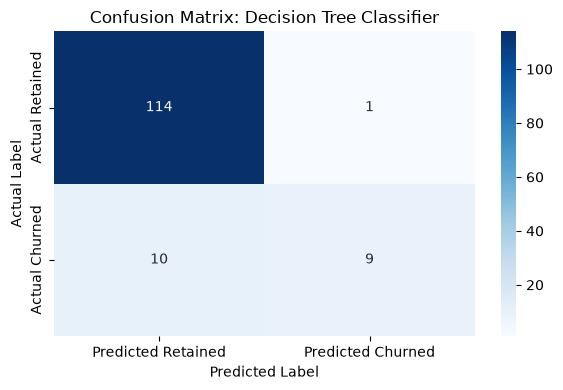

In [4]:
# 7. Classification Report
print('--- Classification Report ---')
print(
    classification_report(
        y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']
    )
)

# 8. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Retained', 'Predicted Churned'],
    yticklabels=['Actual Retained', 'Actual Churned'],
)
plt.title('Confusion Matrix: Decision Tree Classifier', fontsize=12)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

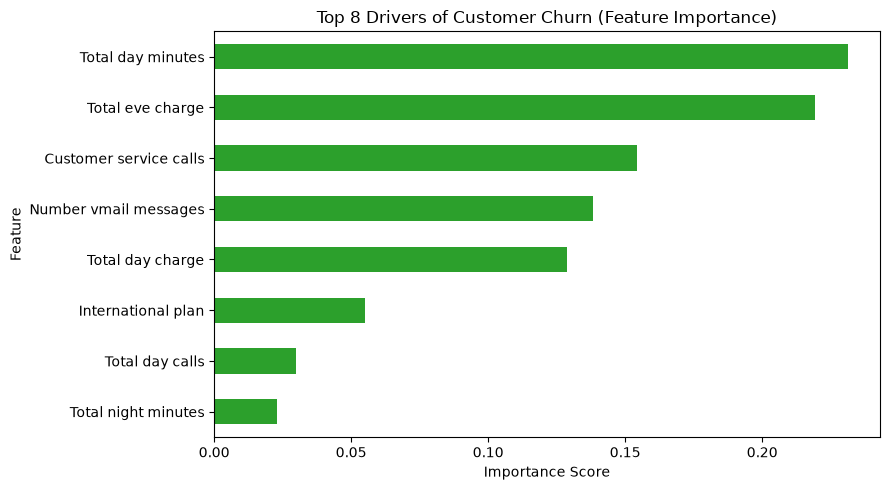

In [5]:
# 9. Extract and plot Feature Importances
importances = pd.Series(
    dt_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.head(8).plot(kind='barh', color='#2ca02c').invert_yaxis()
plt.title('Top 8 Drivers of Customer Churn (Feature Importance)', fontsize=12)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

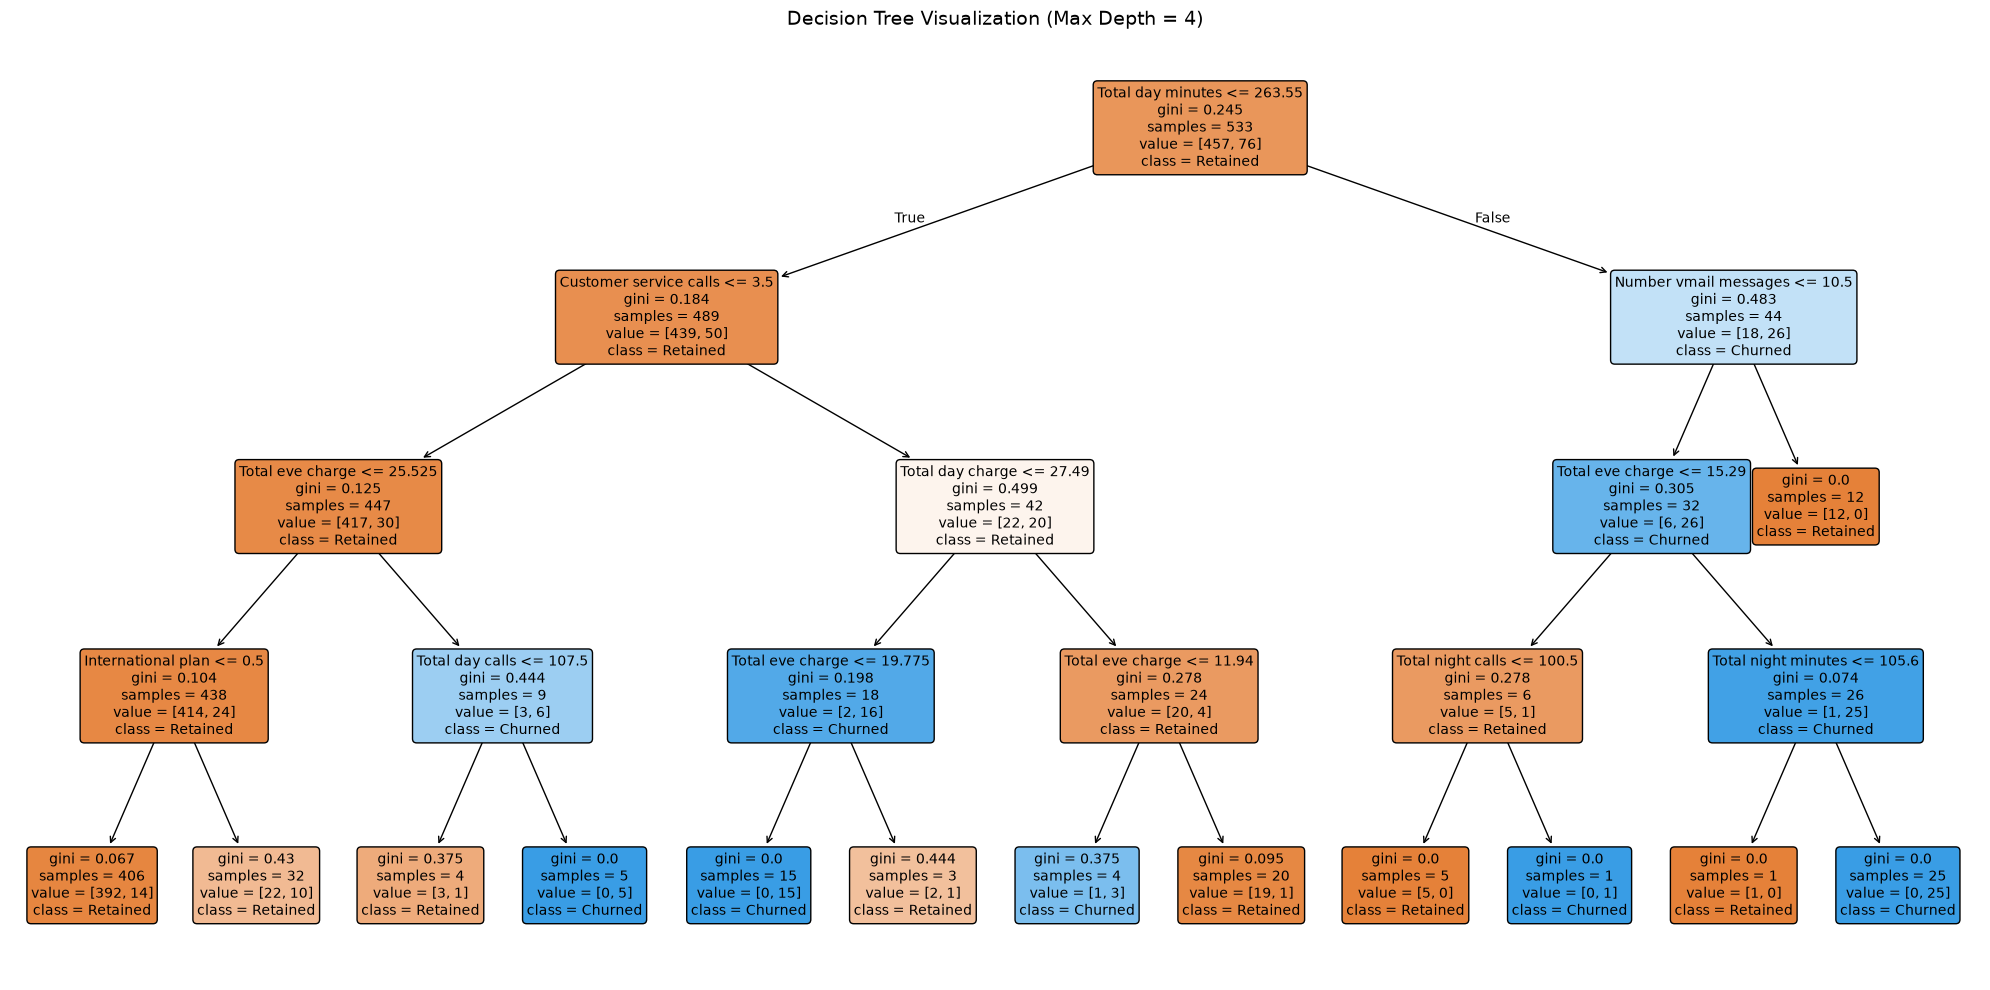

In [6]:
# 10. Visualize the Decision Tree logic rules
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Retained', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title('Decision Tree Visualization (Max Depth = 4)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_logic.png')
plt.show()

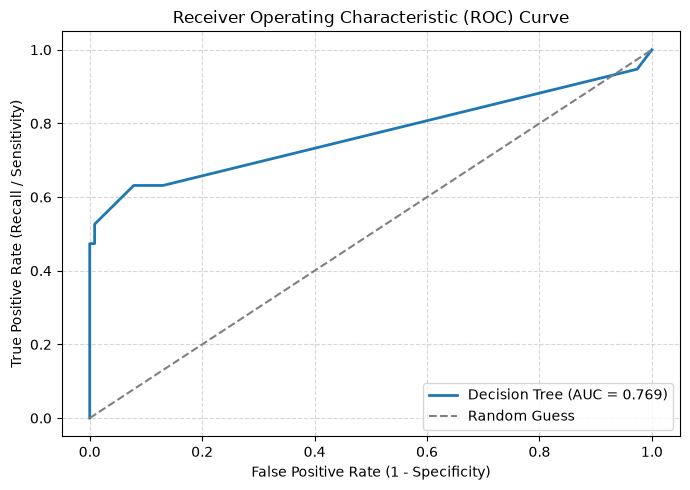

Final Model ROC-AUC Score: 0.7686


In [7]:
# 11. Calculate ROC Curve and Area Under Curve (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    color='#1f77b4',
    linewidth=2,
    label=f'Decision Tree (AUC = {auc_score:.3f})',
)
plt.plot(
    [0, 1],
    [0, 1],
    color='grey',
    linestyle='--',
    linewidth=1.5,
    label='Random Guess',
)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

print(f'Final Model ROC-AUC Score: {auc_score:.4f}')

# Level 3 - Task 1: Ensemble Learning & Hyperparameter Tuning

### Objectives:
1. Implement a **Random Forest Classifier** to improve predictive accuracy and stability over a single decision tree.
2. Perform **5-Fold Stratified Cross-Validation** to evaluate generalization across unseen data folds.
3. Conduct **Hyperparameter Tuning** (`GridSearchCV`) to optimize tree depth, estimator counts, and split criteria.
4. Compare performance metrics directly between baseline Decision Tree and tuned Random Forest models.
  

In [9]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

# 1. Load dataset
desktop_csvs = glob.glob(os.path.expanduser('~/Desktop/*.csv'))
df = pd.read_csv(desktop_csvs[0])

# 2. Binary Encoding
df['International plan'] = (
    df['International plan'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
).fillna(0)
df['Voice mail plan'] = (
    df['Voice mail plan'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
).fillna(0)
df['Churn'] = df['Churn'].astype(int)

# 3. Features and Target
feature_cols = [
    'Account length',
    'Number vmail messages',
    'Total day minutes',
    'Total day calls',
    'Total day charge',
    'Total eve minutes',
    'Total eve calls',
    'Total eve charge',
    'Total night minutes',
    'Total night calls',
    'Total night charge',
    'Total intl minutes',
    'Total intl calls',
    'Total intl charge',
    'Customer service calls',
    'International plan',
    'Voice mail plan',
]

X = df[feature_cols]
y = df['Churn']

# 4. Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(
    f'Train shape: {X_train.shape} | Test shape: {X_test.shape} | Churn Rate:'
    f' {y.mean():.2%}'
)

Train shape: (533, 17) | Test shape: (134, 17) | Churn Rate: 14.24%


In [10]:
# 5. Initialize base models
dt_base = DecisionTreeClassifier(max_depth=4, random_state=42)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

# 6. 5-Fold Stratified Cross-Validation for ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_scores = cross_val_score(
    dt_base, X_train, y_train, cv=cv, scoring='roc_auc'
)
rf_cv_scores = cross_val_score(
    rf_base, X_train, y_train, cv=cv, scoring='roc_auc'
)

print(
    f'Decision Tree 5-Fold CV ROC-AUC: {dt_cv_scores.mean():.4f} (±'
    f' {dt_cv_scores.std():.4f})'
)
print(
    f'Random Forest 5-Fold CV ROC-AUC: {rf_cv_scores.mean():.4f} (±'
    f' {rf_cv_scores.std():.4f})'
)

Decision Tree 5-Fold CV ROC-AUC: 0.8177 (± 0.0647)
Random Forest 5-Fold CV ROC-AUC: 0.9003 (± 0.0247)


In [11]:
# 7. Define Parameter Grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.9089


In [12]:
# 8. Train best models and generate predictions on test split
dt_base.fit(X_train, y_train)
y_pred_dt = dt_base.predict(X_test)
y_prob_dt = dt_base.predict_proba(X_test)[:, 1]

best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# 9. Comparison DataFrame
comparison_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision (Churn)',
            'Recall (Churn)',
            'F1-Score (Churn)',
            'ROC-AUC Score',
        ],
        'Decision Tree': [
            f'{accuracy_score(y_test, y_pred_dt):.4f}',
            f'{precision_score(y_test, y_pred_dt):.4f}',
            f'{recall_score(y_test, y_pred_dt):.4f}',
            f'{f1_score(y_test, y_pred_dt):.4f}',
            f'{roc_auc_score(y_test, y_prob_dt):.4f}',
        ],
        'Tuned Random Forest': [
            f'{accuracy_score(y_test, y_pred_rf):.4f}',
            f'{precision_score(y_test, y_pred_rf):.4f}',
            f'{recall_score(y_test, y_pred_rf):.4f}',
            f'{f1_score(y_test, y_pred_rf):.4f}',
            f'{roc_auc_score(y_test, y_prob_rf):.4f}',
        ],
    }
)

display(comparison_df)

,Metric,Decision Tree,Tuned Random Forest
0,Accuracy,0.9179,0.9254
1,Precision (Churn),0.9000,1.0000
2,Recall (Churn),0.4737,0.4737
3,F1-Score (Churn),0.6207,0.6429
4,ROC-AUC Score,0.7686,0.9066


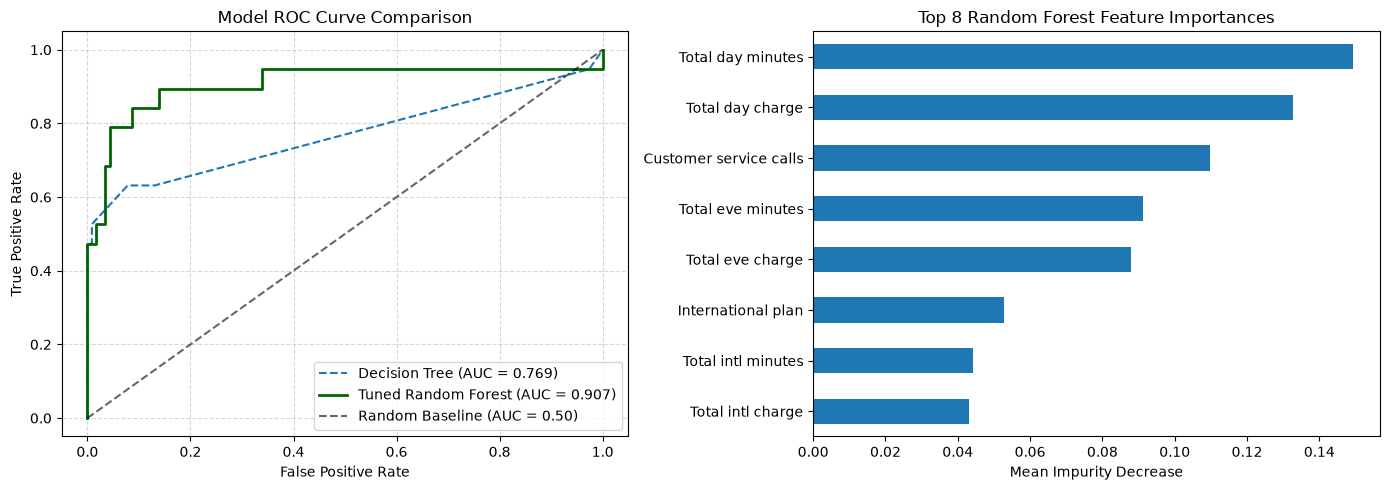

In [13]:
# 10. Side-by-side visualization: ROC Curves and Random Forest Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})',
    linestyle='--',
)
axes[0].plot(
    fpr_rf,
    tpr_rf,
    label=(
        f'Tuned Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
    ),
    linewidth=2,
    color='darkgreen',
)
axes[0].plot(
    [0, 1], [0, 1], 'k--', alpha=0.6, label='Random Baseline (AUC = 0.50)'
)
axes[0].set_title('Model ROC Curve Comparison', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# RF Feature Importances
rf_importances = pd.Series(
    best_rf.feature_importances_, index=feature_cols
).sort_values(ascending=False)
rf_importances.head(8).plot(kind='barh', ax=axes[1], color='#1f77b4').invert_yaxis()
axes[1].set_title('Top 8 Random Forest Feature Importances', fontsize=12)
axes[1].set_xlabel('Mean Impurity Decrease')

plt.tight_layout()
plt.savefig('model_comparison_and_importance.png')
plt.show()